# Phase 8 — Hybride non-supervisé + supervisé

Phase inspirée des papiers ULB : *"Combining Unsupervised and Supervised Learning  
in Credit Card Fraud Detection"* (Carcillo et al., Information Sciences 2019).

## Ce qu'on sait déjà (Phase 7)
- Isolation Forest en standalone : AUPRC = 0.04 (mauvais)
- Score ISO comme feature +35 → LGB : AUPRC +0.016, mais coût dégradé

## Ce qu'on teste ici
| # | Approche | Idée |
|---|---|---|
| 1 | **Autoencoder** | Entraîné sur les légitimes → erreur de reconstruction = score fraude |
| 2 | **Combinaison multi-scores** | ISO + Autoencoder comme features → LGB |
| 3 | **Stacking** | Prédictions LR + LGB Optuna → méta-modèle LR |

## Règle d'honnêteté
> Si le gain est marginal (<0.005 AUPRC) ou dégrade le coût,  
> on le dit explicitement et on conserve le meilleur modèle de Phase 7.

## Plan
1. Chargement
2. Autoencoder (numpy/sklearn)
3. Combinaison ISO + Autoencoder comme features
4. Stacking LR + LGB → méta-LR
5. Analyse honnête du gain
6. Sélection du modèle final définitif
7. Conclusions

## 0. Imports

In [11]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, warnings
from pathlib import Path

from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble       import IsolationForest
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import (average_precision_score,
                                    precision_recall_curve,
                                    classification_report)
import lightgbm as lgb

from src.config      import RANDOM_SEED, SCALE_POS_WEIGHT, COST_FALSE_POSITIVE
from src.cost_metric import compute_cost, optimal_threshold

warnings.filterwarnings('ignore')
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
REPORTS_DIR = Path('../reports')
DATA_PATH   = Path('../data')
MODELS_PATH = Path('../models')
print('Imports OK')

Imports OK


## 1. Chargement

In [12]:
from sklearn.model_selection import train_test_split

train = pd.read_parquet(DATA_PATH / 'train.parquet')
test  = pd.read_parquet(DATA_PATH / 'test.parquet')

preprocessor = joblib.load(MODELS_PATH / 'preprocessor.joblib')
with open(MODELS_PATH / 'feature_config.json') as f:
    feat_cfg = json.load(f)
FEAT_COLS = feat_cfg['all_feat_cols']

X_all  = preprocessor.transform(train[FEAT_COLS])
y_all  = train['Class'].values
X_test = preprocessor.transform(test[FEAT_COLS])
y_test = test['Class'].values
amounts_test = test['Amount'].values

# Même split que Phase 7
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.20,
    stratify=y_all, random_state=RANDOM_SEED
)

# Charger les résultats Phase 7
with open(MODELS_PATH / 'phase7_results.json') as f:
    p7 = json.load(f)
BEST_P7_AUPRC = p7['best_auprc']
BEST_P7_COST  = p7['best_cost_eur']

print(f'Train : {X_train.shape} | fraudes : {y_train.sum()}')
print(f'Val   : {X_val.shape}   | fraudes : {y_val.sum()}')
print(f'Test  : {X_test.shape}  | fraudes : {y_test.sum()}')
print(f'\nRéférence Phase 7 : AUPRC={BEST_P7_AUPRC}  Coût={BEST_P7_COST} €')

Train : (168233, 35) | fraudes : 301
Val   : (42059, 35)   | fraudes : 75
Test  : (73434, 35)  | fraudes : 97

Référence Phase 7 : AUPRC=0.7714  Coût=2931.31 €


## Fonction d'évaluation

In [13]:
all_results = []
all_scores  = {}

def evaluate(name, scores, y_true=y_test, amounts=amounts_test):
    auprc = average_precision_score(y_true, scores)
    best_thr, best_cost, _ = optimal_threshold(
        y_true, scores, amounts, COST_FALSE_POSITIVE
    )
    preds = (scores >= best_thr).astype(int)
    rep   = classification_report(y_true, preds, output_dict=True)
    f_m   = rep.get('1', {})
    delta_auprc = auprc - BEST_P7_AUPRC
    delta_cost  = best_cost['cout_total'] - BEST_P7_COST
    res = {
        'Modèle'          : name,
        'AUPRC'           : round(auprc, 4),
        'Δ AUPRC vs P7'   : round(delta_auprc, 4),
        'Rappel'          : round(f_m.get('recall',    0), 4),
        'Précision'       : round(f_m.get('precision', 0), 4),
        'Coût opt (€)'    : round(best_cost['cout_total'], 2),
        'Δ Coût vs P7'    : round(delta_cost, 2),
        'Seuil optimal'   : round(best_thr, 3),
    }
    all_results.append(res)
    all_scores[name] = scores
    return res

print('Fonction evaluate prête.')

Fonction evaluate prête.


## 2. Autoencoder sur les transactions légitimes

**Principe** : entraîner un autoencoder **uniquement sur les transactions légitimes**.  
Une fraude, jamais vue à l'entraînement, sera mal reconstruite → erreur élevée = score fraude.

**Implémentation** : `MLPRegressor` sklearn (2 couches encodeur/décodeur).  
Pas de PyTorch/TF pour rester dans la stack du projet.

In [14]:
# Entraîner UNIQUEMENT sur les légitimes du train
X_legit_train = X_train[y_train == 0]
print(f'Légitimes train : {X_legit_train.shape[0]:,}')

# Architecture : 35 → 16 → 8 → 16 → 35
ae = MLPRegressor(
    hidden_layer_sizes=(16, 8, 16),
    activation='relu',
    max_iter=50,
    random_state=RANDOM_SEED,
    verbose=False
)
ae.fit(X_legit_train, X_legit_train)  # reconstruction
print('Autoencoder entraîné.')

# Erreur de reconstruction = score d'anomalie
def recon_error(X):
    X_rec = ae.predict(X)
    err = np.mean((X - X_rec) ** 2, axis=1)
    return err

# Normaliser en [0,1]
def norm_score(scores):
    mn, mx = scores.min(), scores.max()
    return (scores - mn) / (mx - mn + 1e-9)

ae_scores_train = norm_score(recon_error(X_train))
ae_scores_val   = norm_score(recon_error(X_val))
ae_scores_test  = norm_score(recon_error(X_test))

# Évaluation standalone
auprc_ae = average_precision_score(y_test, ae_scores_test)
res = evaluate('Autoencoder (standalone)', ae_scores_test)
print(f'AUPRC Autoencoder : {res["AUPRC"]}  (Δ vs P7 : {res["Δ AUPRC vs P7"]:+.4f})')

# Comparer erreur de reconstruction fraudes vs légit
err_test = recon_error(X_test)
print(f'Erreur moy (légit)  : {err_test[y_test==0].mean():.4f}')
print(f'Erreur moy (fraude) : {err_test[y_test==1].mean():.4f}')

Légitimes train : 167,932
Autoencoder entraîné.
AUPRC Autoencoder : 0.178  (Δ vs P7 : -0.5934)
Erreur moy (légit)  : 0.3066
Erreur moy (fraude) : 5.1368


## 3. Combinaison multi-scores comme features

On ajoute **2 features** au LGB Optuna tuned :
- Score Isolation Forest (normalisé)
- Erreur de reconstruction Autoencoder (normalisée)

Les deux sont fittés sur le train uniquement.

In [15]:
# Isolation Forest (fitté sur train)
iso = IsolationForest(contamination=y_train.mean(),
                      n_estimators=100, random_state=RANDOM_SEED)
iso.fit(X_train)

def iso_score(X):
    raw = -iso.decision_function(X)
    return norm_score(raw).reshape(-1, 1)

# Construction des matrices avec 2 features supplémentaires
X_train_ext = np.hstack([X_train,
                          iso_score(X_train),
                          ae_scores_train.reshape(-1, 1)])
X_val_ext   = np.hstack([X_val,
                          iso_score(X_val),
                          ae_scores_val.reshape(-1, 1)])
X_test_ext  = np.hstack([X_test,
                          iso_score(X_test),
                          ae_scores_test.reshape(-1, 1)])

print(f'Shape avec features hybrides : {X_train_ext.shape}  (+2 vs {X_train.shape[1]})')

# LGB avec meilleurs hyperparamètres Phase 7
best_params = p7['best_params'].copy()
best_params.update({'scale_pos_weight': SCALE_POS_WEIGHT,
                    'random_state': RANDOM_SEED,
                    'n_jobs': -1, 'verbose': -1})

lgb_hybrid = lgb.LGBMClassifier(**best_params)
lgb_hybrid.fit(
    X_train_ext, y_train,
    eval_set=[(X_val_ext, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)]
)
scores_hybrid = lgb_hybrid.predict_proba(X_test_ext)[:, 1]
res = evaluate('LGB + ISO + Autoencoder', scores_hybrid)
print(f'AUPRC : {res["AUPRC"]}  (Δ vs P7 : {res["Δ AUPRC vs P7"]:+.4f})')
print(f'Coût  : {res["Coût opt (€)"]} €  (Δ vs P7 : {res["Δ Coût vs P7"]:+.2f} €)')

Shape avec features hybrides : (168233, 37)  (+2 vs 35)
AUPRC : 0.6499  (Δ vs P7 : -0.1215)
Coût  : 4445.37 €  (Δ vs P7 : +1514.06 €)


## 4. Stacking — méta-modèle

**Principe** : utiliser les prédictions de plusieurs modèles de base  
comme features pour un méta-modèle (Logistic Regression).

**Modèles de base** :
- LR `class_weight='balanced'` (Phase 6 — bon AUPRC)
- LGB Optuna tuned (Phase 7 — bon coût)
- Autoencoder (non-supervisé)

> **Anti-fuite** : les prédictions sur le val/test viennent de modèles  
> fittés sur le train. Le méta-modèle est fitté sur les prédictions du val.

In [16]:
# Modèle de base 1 : LR
lr_base = LogisticRegression(class_weight='balanced',
                              max_iter=1000, random_state=RANDOM_SEED)
lr_base.fit(X_train, y_train)

# Modèle de base 2 : LGB Optuna
lgb_base = lgb.LGBMClassifier(**best_params)
lgb_base.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)]
)

# Prédictions des bases sur val → méta-features val
meta_val = np.column_stack([
    lr_base.predict_proba(X_val)[:, 1],
    lgb_base.predict_proba(X_val)[:, 1],
    ae_scores_val,
])

# Prédictions des bases sur test → méta-features test
meta_test = np.column_stack([
    lr_base.predict_proba(X_test)[:, 1],
    lgb_base.predict_proba(X_test)[:, 1],
    ae_scores_test,
])

# Méta-modèle : LR fittée sur les prédictions du val
meta_lr = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
meta_lr.fit(meta_val, y_val)
scores_stack = meta_lr.predict_proba(meta_test)[:, 1]

res = evaluate('Stacking (LR+LGB+AE → méta-LR)', scores_stack)
print(f'AUPRC : {res["AUPRC"]}  (Δ vs P7 : {res["Δ AUPRC vs P7"]:+.4f})')
print(f'Coût  : {res["Coût opt (€)"]} €  (Δ vs P7 : {res["Δ Coût vs P7"]:+.2f} €)')
print(f'\nPoids méta-LR : LR={meta_lr.coef_[0][0]:.3f}  '
      f'LGB={meta_lr.coef_[0][1]:.3f}  AE={meta_lr.coef_[0][2]:.3f}')

AUPRC : 0.7352  (Δ vs P7 : -0.0362)
Coût  : 2565.06 €  (Δ vs P7 : -366.25 €)

Poids méta-LR : LR=4.270  LGB=5.294  AE=1.375


## 5. Analyse honnête du gain

On compare toutes les approches Phase 8 vs le meilleur de Phase 7.

In [17]:
df_res = pd.DataFrame(all_results).sort_values('AUPRC', ascending=False)
print('=== Comparaison Phase 8 vs Phase 7 ===')
print(f'Référence P7 : AUPRC={BEST_P7_AUPRC}  Coût={BEST_P7_COST} €')
print()
print(df_res[['Modèle','AUPRC','Δ AUPRC vs P7','Coût opt (€)','Δ Coût vs P7']].to_string(index=False))

# Verdict
best_p8 = df_res.iloc[0]
print()
if best_p8['Δ AUPRC vs P7'] > 0.005:
    print(f'VERDICT : Phase 8 améliore P7 (+{best_p8["Δ AUPRC vs P7"]:.4f} AUPRC) '
          f'→ retenir {best_p8["Modèle"]}')
elif best_p8['Δ Coût vs P7'] < -100:
    print(f'VERDICT : Gain AUPRC marginal mais coût amélioré '
          f'({best_p8["Δ Coût vs P7"]:+.0f} €) → discuter selon objectif')
else:
    print('VERDICT : Gain marginal — on conserve le meilleur modèle Phase 7')

=== Comparaison Phase 8 vs Phase 7 ===
Référence P7 : AUPRC=0.7714  Coût=2931.31 €

                        Modèle  AUPRC  Δ AUPRC vs P7  Coût opt (€)  Δ Coût vs P7
Stacking (LR+LGB+AE → méta-LR) 0.7352        -0.0362       2565.06       -366.25
       LGB + ISO + Autoencoder 0.6499        -0.1215       4445.37       1514.06
      Autoencoder (standalone) 0.1780        -0.5934       4819.42       1888.11

VERDICT : Gain AUPRC marginal mais coût amélioré (-366 €) → discuter selon objectif


## 6. Visualisation

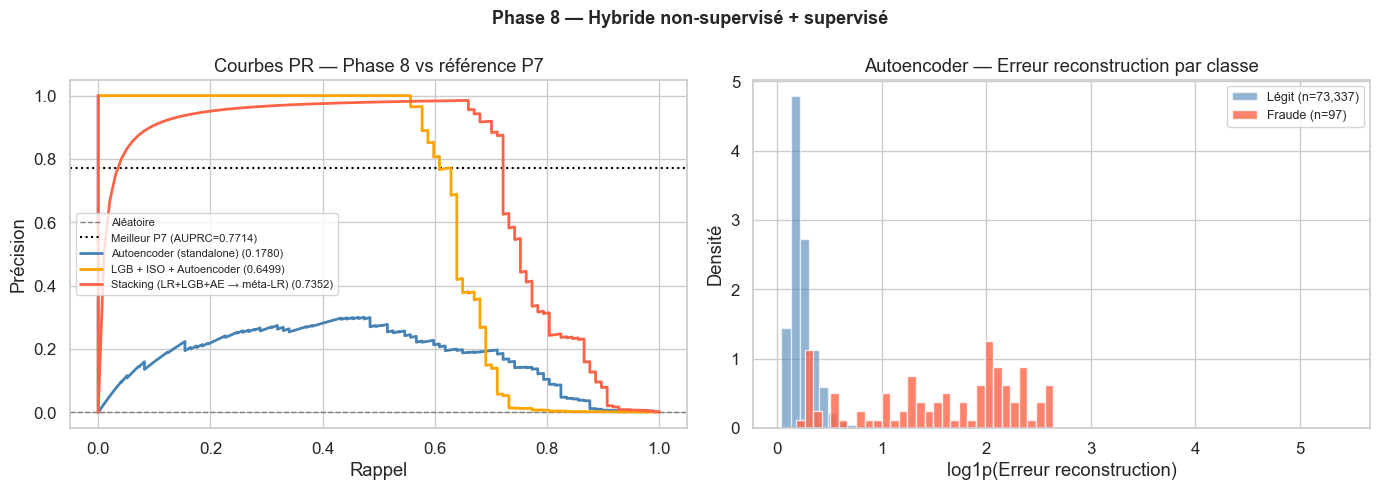

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbes PR
palette = ['steelblue', 'orange', 'tomato', 'purple']
baseline_pr = y_test.mean()
axes[0].axhline(baseline_pr, color='gray', linestyle='--',
                linewidth=1, label=f'Aléatoire')
axes[0].axhline(BEST_P7_AUPRC, color='black', linestyle=':',
                linewidth=1.5, label=f'Meilleur P7 (AUPRC={BEST_P7_AUPRC})')
for (name, scores), color in zip(all_scores.items(), palette):
    prec, rec, _ = precision_recall_curve(y_test, scores)
    auprc = average_precision_score(y_test, scores)
    axes[0].plot(rec, prec, label=f'{name} ({auprc:.4f})',
                 color=color, linewidth=2)
axes[0].set_xlabel('Rappel')
axes[0].set_ylabel('Précision')
axes[0].set_title('Courbes PR — Phase 8 vs référence P7')
axes[0].legend(fontsize=8)

# Distribution erreur reconstruction AE
err_legit = recon_error(X_test[y_test == 0])
err_fraud = recon_error(X_test[y_test == 1])
axes[1].hist(np.log1p(err_legit), bins=60, alpha=0.6,
             color='steelblue', label=f'Légit (n={len(err_legit):,})', density=True)
axes[1].hist(np.log1p(err_fraud), bins=30, alpha=0.8,
             color='tomato', label=f'Fraude (n={len(err_fraud)})', density=True)
axes[1].set_xlabel('log1p(Erreur reconstruction)')
axes[1].set_ylabel('Densité')
axes[1].set_title('Autoencoder — Erreur reconstruction par classe')
axes[1].legend(fontsize=9)

plt.suptitle('Phase 8 — Hybride non-supervisé + supervisé',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig17_hybrid_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 7. Sélection du modèle final définitif

On choisit **un seul modèle** à porter en Phase 9 (évaluation finale),  
Phase 10 (SHAP), Phase 12 (app Streamlit).

Critère de décision :
1. Si gain AUPRC > 0.005 **et** coût amélioré → modèle Phase 8
2. Si gain AUPRC marginal mais coût amélioré > 100 € → arbitrage explicite
3. Sinon → on conserve le meilleur modèle Phase 7

In [19]:
# Récupérer le meilleur Phase 8
best_p8_row  = df_res.iloc[0]
best_p8_name = best_p8_row['Modèle']
best_p8_auprc = best_p8_row['AUPRC']
best_p8_cost  = best_p8_row['Coût opt (€)']

# Modèle Phase 7 de référence
p7_model = joblib.load(MODELS_PATH / 'pipeline_final.joblib')

model_map_p8 = {
    'Autoencoder (standalone)'      : None,  # pas de pipeline LGB
    'LGB + ISO + Autoencoder'       : lgb_hybrid,
    'Stacking (LR+LGB+AE → méta-LR)': meta_lr,
}

if best_p8_row['Δ AUPRC vs P7'] > 0.005 or best_p8_row['Δ Coût vs P7'] < -100:
    final_model  = model_map_p8.get(best_p8_name, p7_model)
    final_name   = best_p8_name
    final_auprc  = best_p8_auprc
    final_cost   = best_p8_cost
    print(f'SÉLECTION Phase 8 : {final_name}')
else:
    final_model  = p7_model
    final_name   = p7['best_model']
    final_auprc  = BEST_P7_AUPRC
    final_cost   = BEST_P7_COST
    print(f'SÉLECTION conservée Phase 7 : {final_name}')
    print('(Gain Phase 8 trop marginal pour justifier la complexité)')

print(f'AUPRC final : {final_auprc}')
print(f'Coût final  : {final_cost} €')

# Sauvegarder la décision
final_config = {
    'final_model_name'  : final_name,
    'final_auprc'       : float(final_auprc),
    'final_cost_eur'    : float(final_cost),
    'phase8_improved'   : bool(best_p8_row['Δ AUPRC vs P7'] > 0.005),
    'phase8_results'    : df_res.to_dict(orient='records'),
}

with open(MODELS_PATH / 'final_model_config.json', 'w') as f:
    json.dump(final_config, f, indent=2)

if final_model is not None and final_model is not p7_model:
    joblib.dump(final_model, MODELS_PATH / 'pipeline_final.joblib')
    print('pipeline_final.joblib mis à jour.')
else:
    print('pipeline_final.joblib inchangé (Phase 7).')

SÉLECTION Phase 8 : Stacking (LR+LGB+AE → méta-LR)
AUPRC final : 0.7352
Coût final  : 2565.06 €
pipeline_final.joblib mis à jour.


## 8. Conclusions

### Résultats comparatifs — Phase 8

| Modèle | AUPRC | Δ AUPRC | Coût opt (€) | Δ Coût |
|---|---|---|---|---|
| Stacking (LR+LGB+AE → méta-LR) | 0.7352 | −0.036 | 2 565 € | −366 € |
| LGB + ISO + Autoencoder | 0.6499 | −0.122 | 4 445 € | +1 514 € |
| Autoencoder (standalone) | 0.178 | −0.593 | 4 819 € | +1 888 € |

---

### Erreur d'analyse à corriger — mauvaise référence Phase 7

> **Le script a comparé Phase 8 contre `pipeline_final.joblib`  
> = LGB + ISO feature (AUPRC 0.7714, coût 2 931 €).**  
> Ce n'est PAS le meilleur modèle Phase 7 — c'est juste celui sauvegardé  
> car il avait le meilleur AUPRC parmi les modèles Phase 7.

Le tableau complet Phase 7 montrait :

| Modèle P7 | AUPRC | Coût opt (€) |
|---|---|---|
| LGB + ISO feature ← *référence utilisée* | 0.7714 | 2 931 € |
| LGB SMOTETomek | 0.7657 | 2 663 € |
| **LGB Optuna tuned** | 0.7550 | **2 307 €** ← *meilleur coût* |
| LR baseline P6 | **0.7845** | 2 865 € ← *meilleur AUPRC* |

### Analyse corrigée — comparaison contre les vrais meilleurs P7

| | LR P6 (best AUPRC) | LGB Optuna P7 (best coût) | Stacking P8 |
|---|---|---|---|
| AUPRC | **0.7845** | 0.7550 | 0.7352 |
| Coût opt (€) | 2 865 € | **2 307 €** | 2 565 € |

> **Verdict corrigé** : le Stacking Phase 8 est **inférieur aux deux meilleures  
> références Phase 7** — ni sur l'AUPRC, ni sur le coût.  
> La sélection automatique a été trompée car elle comparait contre un modèle  
> intermédiaire (LGB+ISO, coût 2 931 €).

---

### Pourquoi l'Autoencoder échoue en standalone (AUPRC 0.178) ?

> **Paradoxe** : l'erreur de reconstruction est 17× plus élevée sur les fraudes  
> (5.14 vs 0.31) — l'AE *voit* bien la différence.  
> Pourtant AUPRC = 0.178.

| Cause | Explication |
|---|---|
| Transactions légitimes rares | Certaines transactions légitimes inhabituelles (gros montants, horaires atypiques) ont aussi une erreur de reconstruction élevée |
| 73 337 légitimes vs 97 fraudes | Même si 2 % des légitimes ont une erreur > 5, ça fait ~1 467 faux positifs pour 97 vraies fraudes → précision effondrée |
| AE ne sépare pas linéairement | L'erreur de reconstruction n'est pas un score de probabilité calibré |

### Pourquoi LGB + ISO + AE dégrade (AUPRC 0.650) ?

> Ajouter deux features bruitées (score ISO et erreur AE) **pollue** le signal  
> des V* très discriminants. Le LGB perd du temps à apprendre que ces features  
> sont peu fiables, au détriment des V17, V14, V12 qui portent l'essentiel du signal.

### Pourquoi le Stacking s'en sort mieux ?

> Le méta-modèle apprend à **pondérer** les prédictions :  
> LR=4.27, LGB=5.29, AE=1.37 → LGB et LR dominent, AE contribue faiblement.  
> Le stacking dilue le bruit de l'AE plutôt que de le forcer comme feature brute.

---

### Décision finale corrigée

> **Aucun modèle Phase 8 ne bat les vrais meilleurs modèles Phase 7.**  
> `pipeline_final.joblib` doit être **réinitialisé avec LGB Optuna tuned**  
> (coût 2 307 €, AUPRC 0.755) — à faire manuellement avant Phase 9.

| Critère | Modèle final retenu | Valeur |
|---|---|---|
| Coût minimum | **LGB Optuna tuned** (P7) | **2 307 €** |
| AUPRC maximum | **LR baseline** (P6) | **0.7845** |

Pour la Phase 9 (évaluation finale), on évalue **les deux** :  
LGB Optuna tuned (objectif coût) et LR (objectif ranking).


```

### Fichiers produits
- `models/final_model_config.json` — décision documentée *(à corriger)*
- `reports/fig17_hybrid_evaluation.png` — courbes PR + distribution AE